In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\satya teja\Downloads\task1ai.csv")

In [4]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(list(df.columns))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [16]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,0,1
1,2,1,1,1,38.0,1,0,71.2833,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,1
3,4,1,1,1,35.0,1,0,53.1000,0,1
4,5,0,3,0,35.0,0,0,8.0500,0,1


In [5]:
df = df.drop(['Name'], axis=1)

In [6]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [7]:
df = df.drop(['Ticket','Cabin'], axis=1)

In [8]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [9]:
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked_Q       0
Embarked_S       0
dtype: int64

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [13]:
df = df.drop("PassengerId", axis=1)

In [29]:
#Noemalize(Standardization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Pclass', 'Age' , 'SibSp' , 'Parch']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.show()

KeyError: 'Salary'

<Figure size 600x400 with 0 Axes>

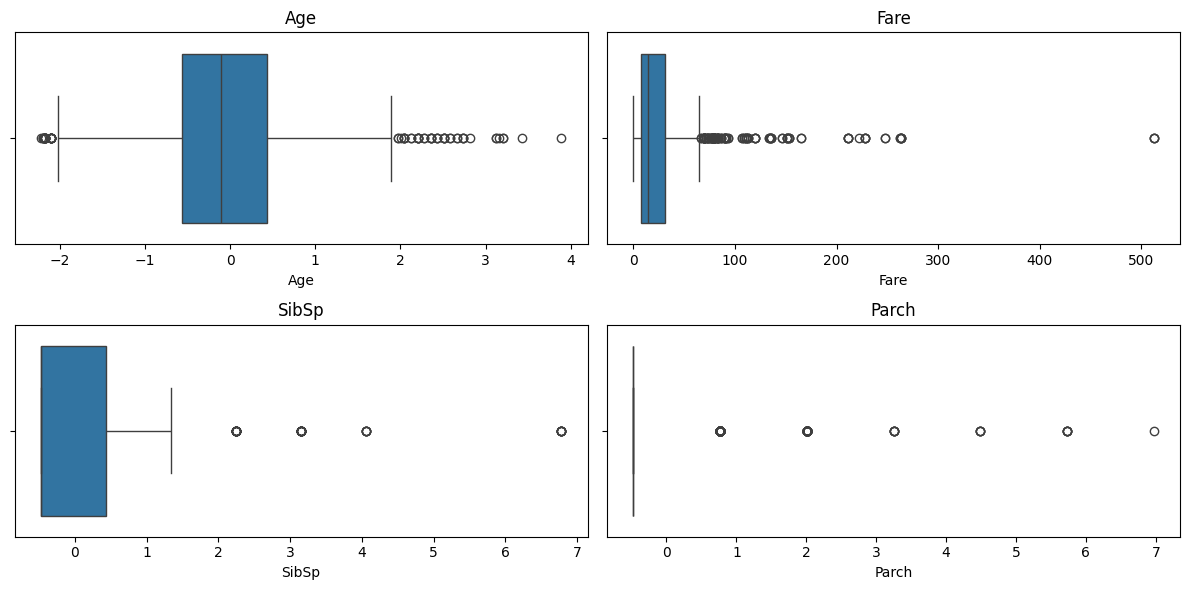

In [31]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [32]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Fare')

In [33]:
df.shape

(718, 9)